# C-MAPSS FD001 — Exploratory Data Analysis

**Scope:** this notebook is EDA only. It looks at the raw data to *justify* the choices made in `src/rul/` (which sensors to keep, the rolling-window idea, and the piecewise-linear RUL cap). No models are trained here — that lives in `rul.model` / `rul.train`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rul import config
from rul.data import compute_rul, load_subset

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Load the data

FD001 has one operating condition and one fault mode (HPC degradation).

In [2]:
train = load_subset('FD001', 'train')
test = load_subset('FD001', 'test')
print('train:', train.shape, '| test:', test.shape,
      '| train engines:', train.unit.nunique())
train.head()

train: (20631, 26) | test: (13096, 26) | train engines: 100


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Engine lifetimes

Each training engine runs to failure. The spread of lifetimes tells us how much history we typically have and motivates the RUL cap.

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


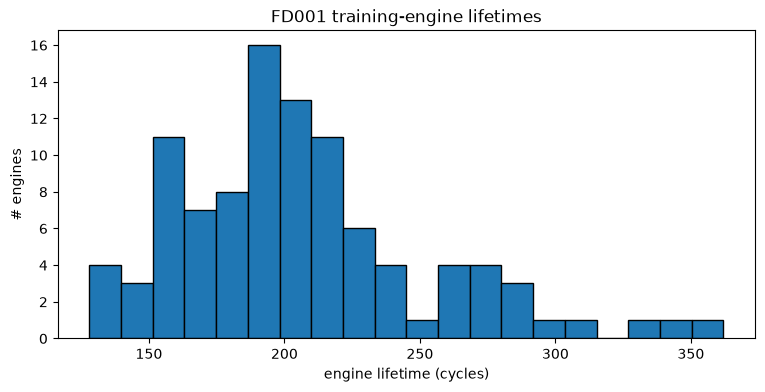

In [3]:
life = train.groupby('unit')['cycle'].max()
print(life.describe().round(1))
plt.hist(life, bins=20, edgecolor='k')
plt.xlabel('engine lifetime (cycles)'); plt.ylabel('# engines')
plt.title('FD001 training-engine lifetimes'); plt.show()

## 3. Constant sensors under a single operating condition

With one operating regime, several sensors never move. `FeatureBuilder` drops any setting/sensor whose std is below `CONSTANT_STD_THRESHOLD` — here we reproduce that filter to see exactly which columns get removed.

In [4]:
cand = config.SETTING_COLS + config.SENSOR_COLS
stds = train[cand].std().sort_values()
constant = stds[stds <= config.CONSTANT_STD_THRESHOLD].index.tolist()
print('Dropped as constant:', constant)
print('\nStd of each candidate column:')
stds

Dropped as constant: ['sensor_1', 'op_setting_3', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']

Std of each candidate column:


sensor_1        0.000000e+00
op_setting_3    0.000000e+00
sensor_10       0.000000e+00
sensor_19       0.000000e+00
sensor_18       0.000000e+00
sensor_16       3.469531e-18
sensor_5        5.329200e-15
op_setting_2    2.930621e-04
sensor_6        1.388985e-03
op_setting_1    2.187313e-03
sensor_15       3.750504e-02
sensor_8        7.098548e-02
sensor_13       7.191892e-02
sensor_21       1.082509e-01
sensor_20       1.807464e-01
sensor_11       2.670874e-01
sensor_2        5.000533e-01
sensor_12       7.375534e-01
sensor_7        8.850923e-01
sensor_17       1.548763e+00
sensor_3        6.131150e+00
sensor_4        9.000605e+00
sensor_14       1.907618e+01
sensor_9        2.208288e+01
dtype: float64

## 4. Sensor trajectories vs. cycle

Informative sensors drift monotonically as the engine ages — exactly the trend the per-engine rolling features are designed to capture.

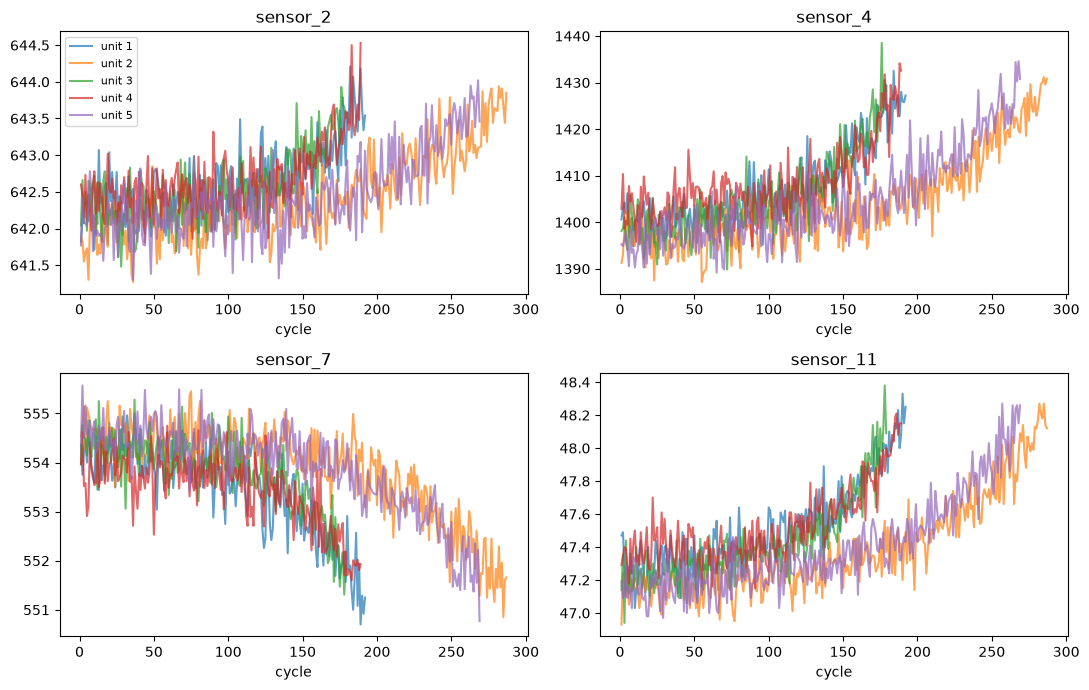

In [5]:
informative = [c for c in config.SENSOR_COLS
               if train[c].std() > config.CONSTANT_STD_THRESHOLD]
sample_units = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, s in zip(axes.ravel(), ['sensor_2', 'sensor_4', 'sensor_7', 'sensor_11']):
    for u in sample_units:
        g = train[train.unit == u]
        ax.plot(g.cycle, g[s], alpha=0.7, label=f'unit {u}')
    ax.set_title(s); ax.set_xlabel('cycle')
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Which sensors track RUL?

Correlation of each informative sensor with the (uncapped) linear RUL. Strong |correlation| means the sensor carries degradation signal.

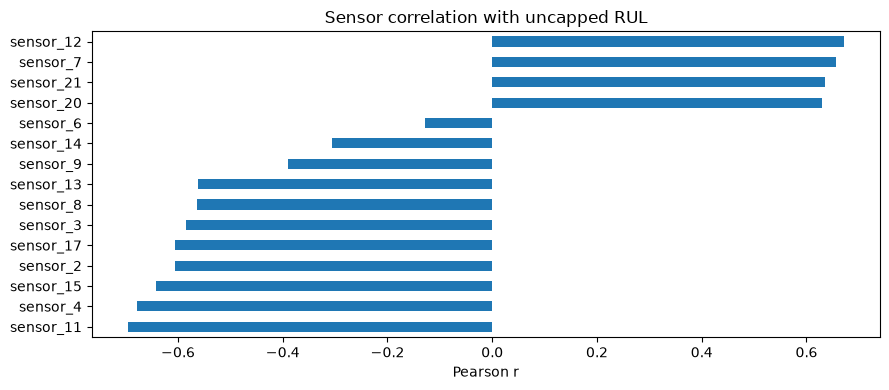

sensor_11   -0.696
sensor_4    -0.679
sensor_15   -0.643
sensor_2    -0.606
sensor_17   -0.606
sensor_3    -0.585
sensor_8    -0.564
sensor_13   -0.563
sensor_9    -0.390
sensor_14   -0.307
sensor_6    -0.128
sensor_20    0.629
sensor_21    0.636
sensor_7     0.657
sensor_12    0.672
Name: RUL, dtype: float64

In [6]:
lab = compute_rul(train, cap=None)
corr = lab[informative + ['RUL']].corr()['RUL'].drop('RUL').sort_values()
corr.plot.barh()
plt.title('Sensor correlation with uncapped RUL'); plt.xlabel('Pearson r')
plt.tight_layout(); plt.show()
corr.round(3)

## 6. Why cap the RUL target?

Early in life an engine is healthy and its sensors are flat, so a strictly linear RUL (which can exceed 300) is not learnable and inflates errors. We clip the training target at `RUL_CAP` = 125 (piecewise-linear RUL, after Heimes 2008).

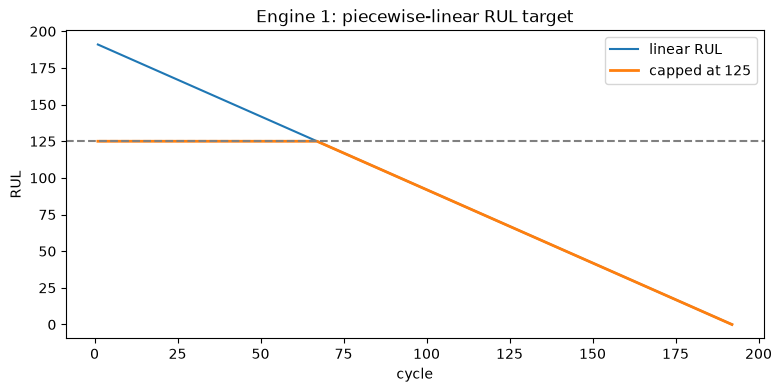

In [7]:
u = 1
lin = compute_rul(train[train.unit == u], cap=None)
cap = compute_rul(train[train.unit == u], cap=config.RUL_CAP)
plt.plot(lin.cycle, lin.RUL, label='linear RUL')
plt.plot(cap.cycle, cap.RUL, label=f'capped at {config.RUL_CAP}', lw=2)
plt.axhline(config.RUL_CAP, ls='--', c='grey')
plt.xlabel('cycle'); plt.ylabel('RUL'); plt.legend()
plt.title(f'Engine {u}: piecewise-linear RUL target'); plt.show()

## Takeaways (feeding `src/rul/`)

1. **Drop constant sensors** — done automatically by a variance threshold in `FeatureBuilder`.
2. **Sensors drift with age** — motivates *per-engine* rolling mean/std/min/max.
3. **Cap the RUL target** — flat early-life health makes a linear target unlearnable; `RUL_CAP = 125`.
4. **Lifetimes vary widely** — splits must be done by engine, never by row.